# 🔍 Mission 4: Generate Insights

```{admonition} Your mission
:class: tip

You now understand the variables. It is time to investigate what they reveal.

In this mission, you will:

- 📊 summarise key indicators
- 🔎 compare values and patterns
- 🏆 identify unusually high and low observations
- 🧠 turn numbers into first insights

🏅 **Badge to unlock:** Insight Hunter


# 🔎 Follow the evidence

A single value tells us very little.

To discover patterns, we need to compare observations and ask:

> **Where do values tend to be high, low, or unusual?**

# 🏙️ Open the Berlin data

We will use **Berlin** as our study area.

> First, let's load the GeoPackage and inspect the available columns. These will show us which indicators we can investigate.

In [1]:
import geopandas as gpd

berlin = gpd.read_file(
    "data/g_raw/berlin_3D_canopy_stats_lczv3_grid100m_urau2021_epsg25833.gpkg"
)

berlin.columns.tolist()

/opt/conda/envs/worker_env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


['tile_id',
 'centroid_x',
 'centroid_y',
 'cell_area',
 'lcz_class_value',
 'chm_area',
 'chm_volume',
 'bldg_area',
 'bldg_volume',
 'geometry']

# 🌳 Follow the canopy clue

We will start with **canopy height** — one of the key indicators used to describe the 3D structure of the urban forest.

> Higher values indicate taller vegetation within a 100 m grid cell, while lower values indicate shorter or less vertically developed vegetation.

In [4]:
# Explore canopy volume as a key urban forest indicator
indicator = "chm_volume"

berlin[indicator].describe()

count     90530.000000
mean      57624.795022
std       62298.854941
min           0.000000
25%       14374.670000
50%       32292.820000
75%       75916.965000
max      297611.280000
Name: chm_volume, dtype: float64

# 📊 Read the summary

The statistics give us a quick picture of the indicator.

> Pay attention to:

>- **mean** → the average
>- **50%** → the median
>- **min** → the lowest value
>- **max** → the highest value

Large differences between these values can be our first clue that the indicator varies considerably across the city.

# 🕵️ Find the extremes

>Which observations have the highest values?

Let's ask Python to rank them.

In [7]:
berlin.nlargest(5, indicator)[[indicator]]

,chm_volume
65100,297611.28
65708,295854.31
90083,295491.85
60206,290160.64
65119,288905.00


And what about the lowest values?

In [8]:
berlin.nsmallest(5, indicator)[[indicator]]

,chm_volume
18,0.0
89,0.0
117,0.0
118,0.0
131,0.0


```{admonition} 🔍 Evidence check
:class: note

Compare the two outputs.

- How different are the highest and lowest values?
- Is the difference small or substantial?
- What might this tell us about variation across the study area?

# 📈 See the pattern

>A histogram helps us see whether values are evenly distributed or concentrated within a particular range.

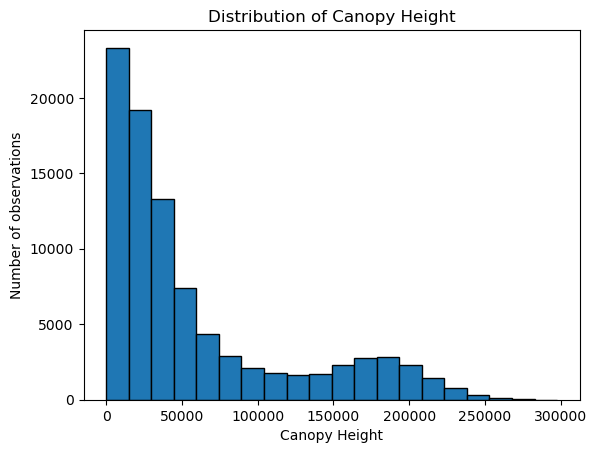

In [12]:
import matplotlib.pyplot as plt

berlin[indicator].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title(f"Distribution of Canopy Height")
plt.xlabel("Canopy Height")
plt.ylabel("Number of observations")
plt.show()

# 👀 What stands out?

Look at the shape of the distribution.

>Are most observations clustered together?

>Or do a few observations have values that are very different from the rest?

Those differences may point us toward places worth investigating more closely.

# ⚖️ Compare indicators

One indicator gives us one perspective.

> Comparing indicators can reveal whether different aspects of urban green infrastructure tell a similar story.

# 🌳 Compare two sides of the canopy

Canopy **area** and canopy **volume** describe different characteristics of urban vegetation.

- `chm_area` tells us how much of a grid cell is covered by canopy.
- `chm_volume` adds the vertical dimension and describes the amount of 3D canopy structure.

Let's compare them.

In [13]:
indicators = ["chm_area", "chm_volume"]

berlin[indicators].describe().T

,count,mean,std,min,25%,50%,75%,max
chm_area,90530.0,3961.142977,2910.194627,0.0,1852.25,3266.25,5639.000,9993.75
chm_volume,90530.0,57624.795022,62298.854941,0.0,14374.67,32292.82,75916.965,297611.28


```{admonition} 🕵️ Investigator challenge
:class: note

Compare **canopy area** and **canopy volume**.

Look at their minimum, median, mean, and maximum values.

🔍 **Think about:** Can two places have a similar amount of canopy cover but very different 3D canopy structures?

# 🧠 Turn patterns into insights

Finding a difference is not yet an insight.

An insight connects the **pattern** to its possible **meaning**.

For example:

> *The indicator varies strongly across observations, suggesting that the measured benefit is not distributed equally throughout the study area.*

Notice the careful wording: the data provides evidence of a pattern, but we should avoid claiming a cause without further analysis.

```{tip}
A useful first insight usually follows this pattern:

**What did you observe? → Where or how does it differ? → Why might it matter?**

# 🗺️ One clue is still missing...

We now know that values differ.

But tables and charts cannot easily tell us **where those differences occur**.

That requires spatial evidence.

>In the next missions, we will start turning these indicators into visual evidence and maps.

```{raw} html
<div class="admonition tip">
  <p class="admonition-title">🎉 Mission Complete — Badge Unlocked!</p>

  <h3>🏆 Insight Hunter</h3>

  <p>You successfully moved from exploring the data to discovering patterns within it.</p>

  <ul>
    <li>✔ Key indicators summarised</li>
    <li>✔ High and low values identified</li>
    <li>✔ Distributions explored</li>
    <li>✔ First insights developed</li>
  </ul>

  <p><strong>Status:</strong> Mission 4 complete</p>

  <button onclick="completeMission4()" style="padding: 10px 16px; font-weight: bold; border-radius: 6px; cursor: pointer;">
    ✅ Complete Mission 4
  </button>

  <p id="mission-4-complete-message" style="font-weight: bold; margin-top: 12px;"></p>
</div>

<script>
function completeMission4() {
  localStorage.setItem("urban_data_mission_4_completed", "true");

  localStorage.setItem("urban_data_badge_4", "Insight Hunter");

  localStorage.setItem(
    "urban_data_mission_4_completed_at",
    new Date().toISOString()
  );

  document.getElementById("mission-4-complete-message").innerHTML =
    "🔓 Mission 5 unlocked! Badge added to your gallery.";
}
</script>

In [ ]:
```{admonition} 🎮 Mission Progress
:class: note, dropdown

**Your Journey**

🟢 **Mission 1: Locate & Retrieve Data ✅ 
🟢 Mission 2: Inspect the Package ✅  
🟢 **Mission 3: Understand the Data ✅    
🟢 Mission 4: Generate Insights ← Current**  
⚪ Mission 5: Create Visual Evidence 🔒  
⚪ Mission 6: Map the City 🔒  
⚪ Mission 7: Extend the Analysis 🔒  
⚪ Final Mission: Tell the Data Story 🔒  

**Progress:** ▰▰▰▰▱▱▱▱ 3/8 Complete

In [ ]:
```{admonition} 🚧 Next Mission Preview
:class: note, dropdown

# 📊 Mission 5: Create Visual Evidence

You have found patterns in the data. Now it is time to **make them visible**.

You will learn how to:

- 📊 turn indicators into clear visualisations
- 🎨 improve plots for easier interpretation
- 🔎 highlight meaningful patterns
- 🧠 communicate what the evidence shows

**Your next challenge: turn numbers into visual evidence.**